# TP Deep QLearning

Dans ce TP, l'objectif est d'implémenter un agent apprenant à faire atterir un vaisseau sur la lune avec l'algorithme Deep Q-Network. Pour cela vous allez utiliser [PyTorch](https://pytorch.org/) et [Gymnasium](https://gymnasium.farama.org/). 

<img src='img/lunarlander.png'  width=500px>

# 1. Consignes

> Compléter ce notebook et les différents fichiers python associés. 
> 
> Répondre aux questions.


> Le code doit être fonctionnel avec l'environnement virtuel du TP. Si d'autres packages que ceux présents dans l'environnement virtuel créé au départ sont nécessaires, vous devez ajouter à votre dépôt un fichier `environnement.yaml` qui est un export de votre environnement virtuel. Ce fichier est obtenu avec la commande suivante:  ```conda env export > environnement.yaml```



# 2. Import des packages

In [3]:
import gymnasium as gym
import random
import torch
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload

def init_seed(seedval):
    torch.manual_seed(seedval)
    np.random.seed(seedval)
    random.seed(seedval)

# 3. Gymnasium

En apprentissage par renforcement, il y a deux concepts fondamentaux : l’agent et l’environnement.
- L’agent est l’entité apprenante qui observe l’environnement et agit sur celui-ci selon les actions disponibles. Son objectif est de maximiser la récompense cumulée qu’il recoit de l’environnement avec lequel il interagit.
- L'agent interagit avec l'environnement à travers la boucle de perception/action ce qui nécessite de définir :
    - Un espace d’action.
    - Un espace d’état (ou observation).
    - Une fonction de récompense.
  
[Gymnasium](https://gymnasium.farama.org/) propose une interface open source unifiée entre un agent et un environnement.
- [Gymnasium](https://gymnasium.farama.org/) propose un ensemble d'environnements pour des tâches d'apprentissage par renforcement. La plupart des environnements ont leur code source disponible sur [GitHub](https://github.com/Farama-Foundation/Gymnasium/tree/main/gymnasium/envs). De nouveaux environnements peuvent aussi être créés à condition qu'ils soient compatibles avec l'interface. 
- Grâce à l'interface unifiée, il est possible de définir indépendamment un agent de l’environnement avec lequel il interagit (et inversement). 
- Lorsque certains pré-traitements sont nécessaires sur les actions, observations, récompenses, ... il est possible d’encapsuler l’environnement dans un **wrapper**, celui-ci se chargera du pré-traitement. 




>  <span style="color:green">Documentation de Gymnasium</span>: [utilisation basique](https://gymnasium.farama.org/content/basic_usage/), [API pour les environnements](https://gymnasium.farama.org/api/env/), ...




##  3.1 - Caractéristiques de l'environnement LunarLander

Dans ce TP, nous allons implémenter un agent qui interagira avec l'environnement **LunarLander**, présenté  [ici](https://gymnasium.farama.org/environments/box2d/lunar_lander/) et le code source est [ici](https://github.com/openai/gym/blob/master/gym/envs/box2d/lunar_lander.py). 2 versions de LunarLander existent: avec des actions discrètes ou des actions continues.

> <span style="color:green">Quelle version de LunarLander choisir pour utiliser le DQN ? Pourquoi ? 

L'environnement LunarLander existe en deux grandes variantes selon le type d'actions autorisees :

- **Version a actions discretes** : c'est la version `LunarLander-v3`, utilisee par defaut avec `gym.make("LunarLander-v3")`. L'agent choisit a chaque pas une action parmi un petit nombre d'actions possibles. L'espace d'actions est `Discrete(4)` : action 0 = ne rien faire, action 1 = activer le moteur lateral gauche, action 2 = activer le moteur principal, action 3 = activer le moteur lateral droit.

- **Version a actions continues** : on l'obtient avec `gym.make("LunarLander-v3", continuous=True)`. Dans cette version, l'action n'est plus un entier parmi 4 choix, mais un vecteur de valeurs reelles. L'agent controle plus finement l'intensite des moteurs. L'espace d'actions est alors continu, typiquement de la forme `Box(...)`, avec des valeurs comprises dans des intervalles donnes.

Pour utiliser DQN, il faut choisir la version a actions discretes de LunarLander (`LunarLander-v3` avec `continuous=False`, valeur par defaut). Dans cette version, l'espace d'actions est fini et peut etre represente par `Discrete(4)`.

C'est exactement le cadre attendu par DQN. Le reseau de neurones ne predit pas directement une action, mais une valeur Q pour chaque action possible dans l'etat courant. Si l'etat est note $s$, le reseau renvoie par exemple un vecteur $Q(s, \cdot)$ contenant une estimation de $Q(s, a)$ pour chaque action discrete $a$. Ensuite, en mode glouton, l'agent choisit l'action qui maximise cette valeur : $a = \arg\max_a Q(s,a)$.

Si l'environnement utilisait des actions continues, cette idee ne fonctionnerait plus directement. Il faudrait chercher le maximum de $Q(s,a)$ sur une infinite d'actions possibles, ce qui n'est pas realiste avec une simple sortie du reseau contenant une valeur par action. Dans ce cas, on utilise plutot des algorithmes adaptes aux espaces d'actions continus, comme DDPG, TD3 ou SAC. Ces methodes apprennent souvent une politique separee, appelee acteur, qui produit directement une action continue, par exemple une intensite de moteur comprise dans un intervalle donne.


Il existe plusieurs fonctions clés pour interagir avec un environnement Gymnasium ( [utilisation basique](https://gymnasium.farama.org/introduction/basic_usage/) et [API](https://gymnasium.farama.org/api/env/)).


> <span style="color:green">Compléter la cellule de code ci-dessous pour afficher:
> 
> - **les dimensions pour les espaces d'états et d'actions** de l'environnement `LunarLander`.
> - les bornes min et max pour les dimensions de l'état
> - un échantillon pris au hasard dans chaque espace. 

In [4]:
env = gym.make("LunarLander-v3")

print("Espace d'etats :", env.observation_space)
print("Dimension de l'etat :", env.observation_space.shape[0])
print("Bornes min de l'etat :", env.observation_space.low)
print("Bornes max de l'etat :", env.observation_space.high)
print("Exemple d'etat :", env.observation_space.sample())

print("Espace d'actions :", env.action_space)
print("Nombre d'actions :", env.action_space.n)
print("Exemple d'action :", env.action_space.sample())

env.close()


Espace d'etats : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Dimension de l'etat : 8
Bornes min de l'etat : [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
Bornes max de l'etat : [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]
Exemple d'etat : [ 0.770536    2.2232325  -8.2241535  -0.84483325 -6.211136    1.2344908
  0.52877086  0.40286282]
Espace d'actions : Discrete(4)
Nombre d'actions : 4
Exemple d'action : 3


### Explication des espaces d'etats et d'actions

**1. L'espace d'etat**

C'est ce que l'agent observe a chaque instant.

Pour LunarLander, l'etat a 8 dimensions :

```text
Dimension de l'etat : 8
```

Cela veut dire qu'a chaque instant, l'environnement donne un vecteur avec 8 nombres, par exemple :

```text
[ 1.4599996  1.0222414 -3.356925 -4.0738473  1.8718783 -7.590859 0.6989383 0.48195848 ]
```

Chaque nombre decrit une information sur le vaisseau :

1. position horizontale
2. position verticale
3. vitesse horizontale
4. vitesse verticale
5. angle du vaisseau
6. vitesse angulaire
7. contact du pied gauche avec le sol
8. contact du pied droit avec le sol

Donc, "dimension de l'etat = 8" veut dire : **un etat est decrit par 8 valeurs**.

**2. Les bornes min et max**

Les bornes disent quelles valeurs sont possibles pour chaque dimension.

Par exemple :

```text
Bornes min de l'etat :
[-2.5, -2.5, -10, -10, -6.28, -10, 0, 0]

Bornes max de l'etat :
[2.5, 2.5, 10, 10, 6.28, 10, 1, 1]
```

Cela veut dire :

- position horizontale entre -2.5 et 2.5
- position verticale entre -2.5 et 2.5
- vitesse horizontale entre -10 et 10
- vitesse verticale entre -10 et 10
- angle entre -6.28 et 6.28
- vitesse angulaire entre -10 et 10
- pied gauche : 0 ou 1
- pied droit : 0 ou 1

Les deux dernieres dimensions valent souvent 0 ou 1 :

```text
0 = pas de contact avec le sol
1 = contact avec le sol
```

**3. L'espace d'action**

L'action, c'est ce que l'agent peut faire.

Ici :

```text
Espace d'actions : Discrete(4)
Nombre d'actions : 4
```

Donc l'agent peut choisir une action parmi 4 :

```text
0 : ne rien faire
1 : allumer le moteur lateral gauche
2 : allumer le moteur principal
3 : allumer le moteur lateral droit
```

**4. Un echantillon au hasard**

Quand on ecrit :

```python
env.observation_space.sample()
```

cela genere un faux etat possible au hasard dans les bornes.

Quand on ecrit :

```python
env.action_space.sample()
```

cela genere une action au hasard, par exemple 0, 1, 2 ou 3.

**Resume simple :**

```text
Etat = ce que l'agent voit.
Dimension de l'etat = nombre d'informations dans l'etat.
Action = ce que l'agent peut faire.
Dimension de l'action = nombre d'actions possibles.
Bornes = valeurs min et max possibles pour chaque information de l'etat.
Sample = exemple genere au hasard.
```

**Attention a ne pas confondre etats et actions**

Il n'y a pas 4 etats. Il y a :

```text
8 valeurs pour decrire l'etat
4 actions possibles
```

Donc :

```text
Etat = observation du vaisseau = 8 dimensions
Action = choix de l'agent = 4 possibilites
```

Exemple d'etat :

```python
etat = [x, y, vx, vy, angle, vitesse_angle, pied_gauche, pied_droit]
```

Donc l'etat contient 8 nombres.

Mais l'action, elle, est juste un choix parmi 4 actions :

```text
0 : ne rien faire
1 : moteur gauche
2 : moteur principal
3 : moteur droit
```

Phrase a retenir : **l'agent observe un etat de dimension 8, puis choisit une action parmi 4**.


> <span style="color:green">A quoi correspond dans le cas du LunarLander une terminaison d'un épisode avec *terminated* à True ? 

Dans LunarLander, `terminated=True` signifie que l'episode s'est termine naturellement parce que l'etat final du probleme est atteint : le vaisseau a atterri, s'est crashe, ou est sorti de la zone autorisee. A ne pas confondre avec `truncated=True`, qui correspond a un arret impose par une limite externe, typiquement un nombre maximal de pas.


## 3.2 Interaction et affichage de l'environnement sur un épisode

> <span style="color:green">Exécuter une instance de l'environnement `LunarLander` pendant un épisode avec des **actions aléatoires**. Afficher l'environnement à chaque pas pour visualiser le comportement du vaisseau. A la fin de l'épisode, afficher la somme des récompenses obtenues sur l'épisode. </span>



In [5]:
# Creation de l'environnement LunarLander-v3.
# render_mode="human" permet d'afficher graphiquement le vaisseau pendant l'episode.
env = gym.make("LunarLander-v3", render_mode="human")

# Initialisation d'un nouvel episode.
# etat contient l'observation initiale du vaisseau : position, vitesse, angle, contacts avec le sol, etc.
# info contient parfois des informations supplementaires donnees par l'environnement.
etat, info = env.reset()

# Variable qui servira a accumuler toutes les recompenses obtenues pendant l'episode.
score = 0

# terminated indique si l'episode est termine naturellement : atterrissage, crash, sortie de zone, etc.
terminated = False

# truncated indique si l'episode est arrete par une limite externe, par exemple un nombre maximal de pas.
truncated = False

# Boucle principale : on continue tant que l'episode n'est ni termine ni tronque.
while not (terminated or truncated):
    # Choix d'une action au hasard parmi les 4 actions possibles de LunarLander.
    # 0 = ne rien faire, 1 = moteur lateral gauche, 2 = moteur principal, 3 = moteur lateral droit.
    action = env.action_space.sample()

    # Application de l'action dans l'environnement.
    # L'environnement avance d'un pas de temps et renvoie le nouvel etat, la recompense,
    # les indicateurs de fin d'episode, et des informations supplementaires.
    etat, recompense, terminated, truncated, info = env.step(action)

    # Ajout de la recompense du pas courant au score total de l'episode.
    score += recompense

# Affichage de la somme des recompenses obtenues pendant tout l'episode.
# Plus ce score est eleve, meilleur est le comportement de l'agent.
print("Somme des recompenses :", score)

# Fermeture propre de l'environnement et de la fenetre graphique.
env.close()


Somme des recompenses : -426.705871194017


# 4. Agent simple (sans apprentissage)

Vous devez maintenant implémenter un **agent simple** qui utilise une **Q fonction paramétrée** (réseau de neurones) pour choisir ses actions selon une stratégie $\epsilon$-greedy (mais sans apprentissage pour l'instant).

> <span style="color:green">- Quels éléments seront en entrée du NN ? En sortie ? Quelle sera la dimension de l'entrée ? De la sortie ? </span>

Le reseau de neurones prend en entree **l'etat courant** observe par l'agent. Pour LunarLander, cet etat est un vecteur de dimension 8 : position, vitesse, angle, vitesse angulaire, et contacts des deux pieds avec le sol. La dimension d'entree du reseau est donc **8**.

En sortie, le reseau ne renvoie pas directement une action. Il renvoie une estimation de la valeur Q pour chaque action possible. Comme LunarLander discret possede 4 actions, la sortie est un vecteur de dimension **4** :

```text
entree du reseau  : etat s de dimension 8
sortie du reseau  : [Q(s,0), Q(s,1), Q(s,2), Q(s,3)] de dimension 4
```

Chaque valeur de sortie represente l'interet estime de faire l'action correspondante dans l'etat courant. L'action choisie en mode glouton sera celle qui a la plus grande valeur Q.


> <span style="color:green">- Quelle fonction d'activation sera utilisée sur le dernière couche du réseau ? Pourquoi ? </span>

Sur la derniere couche, on n'utilise **pas de fonction d'activation** : la sortie est lineaire. La raison est que les valeurs Q sont des scores reels qui peuvent etre positifs, negatifs, petits ou grands. Si on mettait une sigmoide, les valeurs seraient forcees entre 0 et 1 ; si on mettait une ReLU, les valeurs negatives seraient impossibles. Or, en apprentissage par renforcement, une action peut avoir une valeur Q negative si elle mene a de mauvaises recompenses.

On utilise donc des activations comme ReLU dans les couches cachees, mais la derniere couche reste lineaire pour laisser le reseau predire librement les valeurs Q.


- définir l'architecture du réseau de neurones en complétant `QNN.py`. Ce réseau va approximer la Q-fonction comme dans DQN (pour l'instant, les poids du réseau ne seront pas mis à jour, le réseau est uniquement utilisé en prédiction).

- définir un agent simple en complétant `agentsimple.py`: il utilisera la prédiction du réseau de neurones pour choisir ses actions selon une stratégie d’exploration $\epsilon$-greedy.

- utiliser cet agent sur plusieurs épisodes dans `LunarLander`. Vous utiliserez une décroissance de l'exploration, i.e. que $\epsilon$ va décroitre à chaque épisode, en démarrant à une valeur élevée (beaucoup d'exploration) et avec une borne minimum. Ainsi, au premier épisode, $\epsilon=\epsilon_{start}$, et à chaque épisode, $\epsilon=max(\epsilon_{end}, \epsilon_{decay}*\epsilon)$. Par exemple sur 1000 épisodes, les valeurs peuvent être $\epsilon_{start} = 1.0$, $\epsilon_{end} = 0.01$ et $\epsilon_{decay} = 0.995$.

- proposer un tracé de la somme des récompenses obtenues par épisode (vous pouvez utiliser le fichier `utils.py`, le wrapper [RecordEpisodeStatistics](https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.RecordEpisodeStatistics ),  ...).


In [6]:
#Reload all modules every time before executing the Python code typed
%autoreload 2
# import depuis un fichier python local 
from QNN import QNN 
from agentsimple import AgentSimple
import utils

Score moyen : -172.7385216437983
Dernier epsilon : 0.6057704364907278


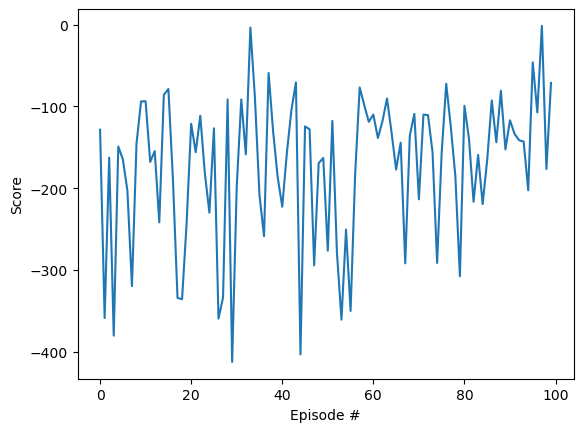

In [7]:
# Creation de l'environnement sans affichage graphique pour aller plus vite.
env = gym.make("LunarLander-v3")

# Recuperation automatique des dimensions depuis l'environnement.
dim_etat = env.observation_space.shape[0]
dim_action = env.action_space.n

# Creation de l'agent simple.
# Il contient un reseau QNN, mais ce reseau n'est pas encore entraine.
agent = AgentSimple(dim_etat, dim_action)

# Parametres de la strategie epsilon-greedy.
# Au debut epsilon est grand : l'agent explore beaucoup.
# Puis epsilon diminue progressivement jusqu'a eps_end.
nb_episodes = 100
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995
eps = eps_start

scores = []

for episode in range(nb_episodes):
    # reset() demarre un nouvel episode et renvoie l'etat initial.
    etat, info = env.reset()

    score = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        # Choix de l'action avec la strategie epsilon-greedy.
        # Avec probabilite eps : action aleatoire.
        # Sinon : action avec la plus grande valeur Q predite par le reseau.
        action = agent.action_egreedy(etat, eps)

        # Application de l'action dans l'environnement.
        etat, recompense, terminated, truncated, info = env.step(action)
        score += recompense

    scores.append(score)

    # Decroissance de l'exploration.
    # eps est la probabilite de choisir une action aleatoire.
    # Au debut, eps est grand : l'agent explore beaucoup.
    # A chaque episode, on multiplie eps par eps_decay pour le diminuer progressivement.
    # max(eps_end, ...) empeche eps de descendre sous eps_end.
    # Donc l'agent explore de moins en moins, mais garde toujours un minimum d'exploration.
    eps = max(eps_end, eps_decay * eps)

env.close()

print("Score moyen :", np.mean(scores))
print("Dernier epsilon :", eps)
# Affichage de la courbe des scores obtenus episode par episode.
# scores contient une somme de recompenses par episode.
# Cette fonction trace donc l'evolution du score au fil des episodes.
# Ici, la courbe reste instable car AgentSimple n'apprend pas encore.
utils.plot_sumrwdperepi(scores)


### Interpretation du resultat de l'agent simple

Ce resultat est normal : le score moyen est negatif et la courbe est tres instable parce que cet agent est un **agent simple sans apprentissage**.

Meme s'il utilise un reseau de neurones, les poids du reseau sont encore aleatoires. Donc l'agent ne sait pas vraiment piloter le vaisseau. A chaque pas, il fait soit :

```text
une action aleatoire avec probabilite epsilon
ou l'action que son reseau non entraine croit etre la meilleure
```

Comme le reseau n'a pas encore appris, ses "meilleures actions" ne veulent pas dire grand-chose pour l'instant.

Le score moyen negatif est donc attendu. Pour LunarLander, un score tres negatif correspond generalement a un mauvais comportement, souvent un crash ou une mauvaise gestion du carburant. Un score autour de 200 indique au contraire que l'environnement est considere comme resolu.

Cette partie sert donc surtout a verifier que le reseau `QNN`, l'agent `AgentSimple`, la strategie epsilon-greedy, la boucle sur plusieurs episodes et le trace des recompenses fonctionnent correctement. La vraie amelioration viendra dans la partie suivante, quand on mettra a jour les poids du reseau avec le Deep Q-Learning.


# 5. Deep QLearning avec Replay Buffer

L'algorithme (sans réseau cible) est donné ci-dessous:

<img src='img/algodqnv2.png'  width=700px>


- La phase d'**interaction** avec l'environnement (sans apprentissage): phase pendant laquelle l'agent stocke en mémoire toutes les transitions rencontrées. Une transition est un tuple `(état,action,état_suivant,récompense,fin_episode)`. La mémoire (ou buffer) a une taille maximale; lorsqu’elle est dépassée, les nouvelles transitions remplacent les plus anciennes. 

- La phase d'**apprentissage** permet de mettre à jour les paramètres de la fonction *Q* à partir d'échantillons de transitions (minibatch, de taille $d=64$ par exemple) présentes dans la mémoire. La phase d'apprentissage est réalisée tous les `t` pas (ou actions) dans l'environnement (par ex. $t=4$).

- La classe `ReplayBuffer` du fichier `replaybuffer.py` permet de stocker des transitions dans une mémoire et de récupérer des minibatch de transitions.


Vous devez implémenter l'algorithme du **Deep QLearning avec ReplayBuffer** donné ci-dessus.

Remarque: 
- vous n'utiliserez pas de réseau cible (*target network*) pour l'instant.
- Pour l'optimizer, SGD et [Adam](https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/) sont particulièrement adaptés. 
- Dans la phase d'apprentissage, les éléments récupérés dans un minibatch  sont des tenseurs de taille $d \times dim\_element$. Vous devez dans cette phase faire des calculs tensoriel directement (et pas de boucle for sur $d$ !)
- Voici aussi des liens vers différentes fonctions de PyTorch qui pourraient vous être utiles: [unsqueeze](https://pytorch.org/docs/stable/generated/torch.unsqueeze.html), [gather](https://pytorch.org/docs/stable/generated/torch.gather.html)


> <span style="color:green">Compléter la classe `AgentDQN`</span> 
>
> <span style="color:green">Implémenter l'algorithme dans la fonction *dqnalgo* ci-dessous.  </span> 


 
 

In [8]:
#Reload all modules every time before executing the Python code typed
%autoreload 2
import gymnasium as gym
import numpy as np
import utils
from replaybuffer import ReplayBuffer
from agentdqn import AgentDQN


In [9]:
def dqnalgo(agent, env, nb_episodes, eps_start, eps_end, eps_decay):
    """
    Execute l'algorithme DQN avec replay buffer.

    Retourne la somme des recompenses obtenues a chaque episode.
    """

    # Liste qui contiendra le score total de chaque episode.
    scores = []

    # Epsilon controle l'exploration dans la strategie epsilon-greedy.
    eps = eps_start

    # Compteur global de pas dans l'environnement.
    # Il sert a declencher l'apprentissage tous les agent.update_every pas.
    nb_pas = 0

    for episode in range(nb_episodes):
        # Debut d'un nouvel episode.
        # env.reset() reinitialise l'environnement.
        # Il remet le vaisseau dans une position initiale et renvoie deux choses :
        #
        # 1. etat : l'observation initiale du vaisseau.
        # Pour LunarLander, c'est un tableau de 8 valeurs :
        # etat = [x, y, vx, vy, angle, vitesse_angle, pied_gauche, pied_droit]
        #
        # Exemple possible :
        # etat = [0.002, 1.41, 0.21, 0.32, -0.01, -0.04, 0.0, 0.0]
        #
        # Ces valeurs correspondent a :
        # - position horizontale
        # - position verticale
        # - vitesse horizontale
        # - vitesse verticale
        # - angle
        # - vitesse angulaire
        # - contact du pied gauche
        # - contact du pied droit
        #
        # 2. info : un dictionnaire avec des informations supplementaires.
        # Souvent, dans LunarLander, on ne l'utilise pas vraiment.
        # Il peut etre vide : {}
        #
        # Donc etat, info = env.reset() signifie :
        # - reinitialiser l'environnement
        # - recuperer l'etat initial
        # - recuperer les informations supplementaires
        etat, info = env.reset()
        score = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            # 1. INTERACTION : l'agent choisit une action selon epsilon-greedy.
            action = agent.action_egreedy(etat, eps)  #indice de l'action, acrion = int

            # L'environnement applique l'action et renvoie la transition.
            etat_suivant, recompense, terminated, truncated, info = env.step(action)
            fin_episode = terminated or truncated

            # 2. STOCKAGE : on memorise la transition dans le replay buffer.
            agent.phase_interaction(etat, action, recompense, etat_suivant, fin_episode)

            # Mise a jour de l'etat courant et du score de l'episode.
            etat = etat_suivant
            score += recompense
            nb_pas += 1

            # 3. APPRENTISSAGE : tous les t pas, on tire un minibatch dans le buffer
            # et on met a jour les poids du reseau Q.
            # Ici t = agent.update_every, par defaut 4.
            if nb_pas % agent.update_every == 0:
                agent.phase_apprentissage()

        # On sauvegarde le score total de l'episode termine.
        scores.append(score)

        # Decroissance progressive de l'exploration.
        eps = max(eps_end, eps_decay * eps)

        if (episode + 1) % 50 == 0:
            print("Episode", episode + 1, "score moyen recent", np.mean(scores[-50:]), "epsilon", eps)

    return scores


>
> <span style="color:green">Utiliser cet agent sur plusieurs épisodes dans l'environnement `LunarLander`. Vous proposerez un tracé de la somme des récompenses obtenues par épisode (vous pouvez utiliser `utils.py`).</span> 


Episode 50 score moyen recent -190.45797797234616 epsilon 0.778312557068642
Episode 100 score moyen recent -155.19898017401619 epsilon 0.6057704364907278
Episode 150 score moyen recent -94.0424961139329 epsilon 0.47147873742168567
Episode 200 score moyen recent -109.68408221272293 epsilon 0.3669578217261671
Episode 250 score moyen recent -28.913221301738236 epsilon 0.285607880564032
Episode 300 score moyen recent 32.17556810035739 epsilon 0.22229219984074702
Score moyen final sur les 50 derniers episodes : 32.17556810035739


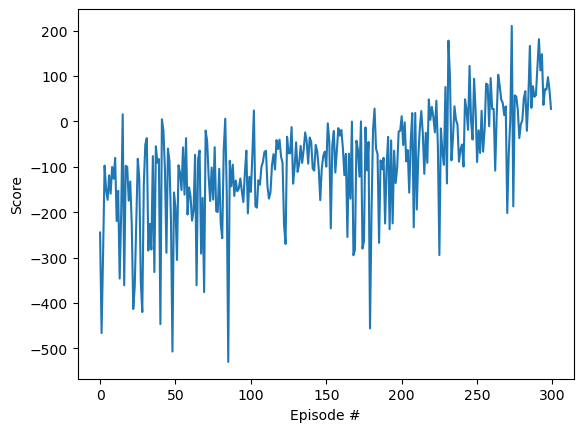

In [10]:
# Creation de l'environnement LunarLander.
env = gym.make("LunarLander-v3")

# Dimensions recuperees directement depuis l'environnement.
dim_etat = env.observation_space.shape[0]
dim_action = env.action_space.n

# Creation de l'agent DQN avec replay buffer.
agent = AgentDQN(dim_etat, dim_action)

# Parametres d'entrainement.
# Pour un test rapide, on peut garder 300 episodes.
# Pour obtenir un agent vraiment meilleur, il faut souvent augmenter ce nombre.
nb_episodes = 300
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995

scores_dqn = dqnalgo(agent, env, nb_episodes, eps_start, eps_end, eps_decay)
env.close()

print("Score moyen final sur les 50 derniers episodes :", np.mean(scores_dqn[-50:]))
utils.plot_sumrwdperepi(scores_dqn)


> <span style="color:green">Faites maintenant une moyenne sur différents seed, avec un apprentissage par seed, et tracer le résultat (somme des récompenses par épisodes) moyenné sur ces seed. Vous utiliserez `init_seed()` et pouvez utiliser `utils.py`.</span> </span> 

Seed 0
Episode 50 score moyen recent -149.26828287208124 epsilon 0.778312557068642
Episode 100 score moyen recent -107.25720237686801 epsilon 0.6057704364907278
Episode 150 score moyen recent -77.86586214334766 epsilon 0.47147873742168567
Episode 200 score moyen recent -32.87585128281822 epsilon 0.3669578217261671
Seed 1
Episode 50 score moyen recent -153.10212109597893 epsilon 0.778312557068642
Episode 100 score moyen recent -92.70448885271792 epsilon 0.6057704364907278
Episode 150 score moyen recent -81.88133055888953 epsilon 0.47147873742168567
Episode 200 score moyen recent -28.4352884015403 epsilon 0.3669578217261671
Seed 2
Episode 50 score moyen recent -170.44559371215502 epsilon 0.778312557068642
Episode 100 score moyen recent -108.3089975526654 epsilon 0.6057704364907278
Episode 150 score moyen recent -70.87742140389227 epsilon 0.47147873742168567
Episode 200 score moyen recent -83.80865375838862 epsilon 0.3669578217261671


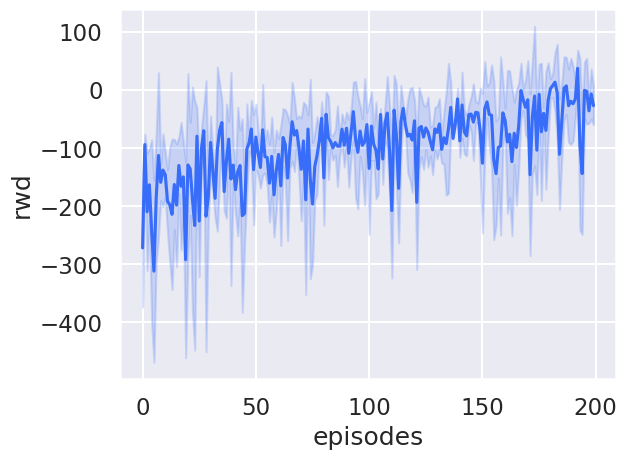

In [11]:
# Evaluation moyenne sur plusieurs seeds.
# Chaque seed correspond a un nouvel entrainement complet d'un nouvel agent.
# Cela permet de lisser le hasard lie a l'initialisation du reseau,
# aux actions aleatoires et aux transitions tirees du replay buffer.

seeds = [0, 1, 2]
nb_episodes = 200
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995

# Liste qui contiendra une liste de scores par seed.
# Exemple final :
# scores_over_seeds = [
#     scores_seed_0,
#     scores_seed_1,
#     scores_seed_2,
# ]
scores_over_seeds = []

for seed in seeds:
    print("Seed", seed)

    # Fixe les sources principales de hasard pour rendre l'experience plus reproductible.
    # init_seed(seed) fixe notamment random, numpy et torch.
    # Ainsi, si on relance avec la meme seed, l'experience est plus facilement reproductible.
    init_seed(seed)

    # Creation d'un nouvel environnement pour cette seed.
    # On repart d'un environnement propre pour chaque entrainement.
    env = gym.make("LunarLander-v3")

    # Initialise aussi le hasard propre a l'environnement.
    # Cela peut influencer l'etat initial du vaisseau.
    env.reset(seed=seed)

    # Creation d'un nouvel agent pour cette seed.
    # env.observation_space.shape[0] vaut 8 pour LunarLander : dimension de l'etat.
    # env.action_space.n vaut 4 pour LunarLander discret : nombre d'actions.
    # Cette ligne est donc equivalente a AgentDQN(8, 4).
    # Important : un nouvel agent signifie un nouvel entrainement independant.
    agent = AgentDQN(env.observation_space.shape[0], env.action_space.n)

    # Entrainement de cet agent avec la fonction dqnalgo.
    # scores_seed est une liste contenant le score obtenu a chaque episode.
    # Exemple : scores_seed = [-300, -250, -180, ...]
    scores_seed = dqnalgo(agent, env, nb_episodes, eps_start, eps_end, eps_decay)

    # On sauvegarde les scores de cette seed dans la liste globale.
    scores_over_seeds.append(scores_seed)

    # Fermeture de l'environnement de cette seed.
    env.close()

# Trace la moyenne des scores par episode sur les differentes seeds,
# avec une indication de la variabilite entre les runs.
utils.plot_sumrwdperepi_overseed(scores_over_seeds)


# 6. Deep QLearning avec réseau cible

Il se peut que votre agent précédent apprenne des comportements intéressants mais qu’ils soient très instables. On va maintenant ajouter un réseau cible pour l'améliorer.

> <span style="color:green"> Quelle est la cause des instabilités de l'algorithme précédent ? Pourquoi le réseau cible améliore ces instabilités ?</span> 

Dans le DQN precedent, le meme reseau est utilise pour deux roles en meme temps : predire $Q(s,a)$ et calculer la cible $r + \gamma \max_{a'} Q(s',a')$. Or ce reseau est modifie a chaque mise a jour. La cible que l'on essaie d'atteindre bouge donc en meme temps que la prediction. Cela rend l'apprentissage instable : le reseau court apres une cible mouvante.

Le reseau cible corrige ce probleme en utilisant deux reseaux :

```text
reseau principal Q_local  : reseau entraine a chaque mise a jour
reseau cible Q_target     : reseau utilise pour calculer la cible DQN
```

Le reseau cible n'est pas mis a jour a chaque gradient step. Il est recopie depuis le reseau principal seulement toutes les N mises a jour. La cible reste donc plus stable pendant plusieurs apprentissages, ce qui limite les oscillations et les divergences.

Phrase a retenir : **le reseau cible stabilise DQN parce qu'il evite de calculer la cible avec le meme reseau que celui que l'on modifie immediatement.**


L'algorithme DQN (avec réseau cible) est donné ci-dessous:

<img src='img/DQNcible.png'  width=500px>


Le réseau cible sera mis à jour toutes les N étapes d'apprentissage (300 par exemple si $t=4$) en recopiant entièrement le réseau de neurone original dans le duplicat.

Pour copier des poids d'un réseau de neurone vers un autre, la méthode `copy_` peut être appelée sur les paramètres:

`for param_duplicat, param_source in zip(model_duplicat.parameters(), model_source.parameters()):`
           
`param_duplicat.data.copy_(param_source.data)`

> <span style="color:green"> Compléter la classe `AgentDQNCible` pour implémenter un agent apprenant avec DQN (deep QLearning et *target network*).</span> 






> <span style="color:green">Utiliser cet agent **dans l'algorithme dqnalgo précédent**. Vous proposerez un tracé de la somme des récompenses obtenues par épisode sur plusieurs seed.</span> 

In [12]:
#Reload all modules every time before executing the Python code typed
%autoreload 2
import gymnasium as gym
import numpy as np
import utils
from agentdqncible import AgentDQNCible


Seed 0
Episode 50 score moyen recent -149.10661360847647 epsilon 0.778312557068642
Episode 100 score moyen recent -117.32502293662691 epsilon 0.6057704364907278
Episode 150 score moyen recent -83.28839635809649 epsilon 0.47147873742168567
Episode 200 score moyen recent -65.04173601488824 epsilon 0.3669578217261671
Seed 1
Episode 50 score moyen recent -178.15221330258174 epsilon 0.778312557068642
Episode 100 score moyen recent -132.91636755699597 epsilon 0.6057704364907278
Episode 150 score moyen recent -99.23506917475288 epsilon 0.47147873742168567
Episode 200 score moyen recent -37.83621465368746 epsilon 0.3669578217261671
Seed 2
Episode 50 score moyen recent -171.8161519803486 epsilon 0.778312557068642
Episode 100 score moyen recent -113.19803050052502 epsilon 0.6057704364907278
Episode 150 score moyen recent -74.00175706337438 epsilon 0.47147873742168567
Episode 200 score moyen recent -38.333268643804495 epsilon 0.3669578217261671


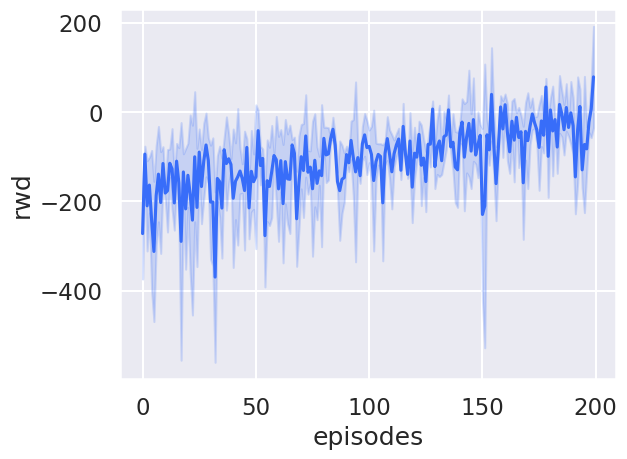

In [13]:
# On reutilise la fonction dqnalgo precedente.
# La seule difference est le type d'agent : AgentDQNCible au lieu de AgentDQN.

seeds = [0, 1, 2]
nb_episodes = 200
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995

scores_cible_over_seeds = []

for seed in seeds:
    print("Seed", seed)
    init_seed(seed)

    env = gym.make("LunarLander-v3")
    env.reset(seed=seed)

    agent_cible = AgentDQNCible(
        env.observation_space.shape[0],
        env.action_space.n,
        target_update_every=300,
    )

    scores_seed = dqnalgo(agent_cible, env, nb_episodes, eps_start, eps_end, eps_decay)
    scores_cible_over_seeds.append(scores_seed)

    env.close()

utils.plot_sumrwdperepi_overseed(scores_cible_over_seeds)


# 6. Sauvegarde d'un agent

> <span style="color:green"> Sauvegarder un agent qui a correctement appris dans un fichier 'monAgentDQN.pth'. Vous préciserez ci-dessous les hyperparamètres utilisés pour cet agent. </span> 



In [14]:
import torch
from agentdqn import AgentDQN
from agentdqncible import AgentDQNCible

# Sauvegarde d'un agent entraine dans un fichier.
#
# L'entrainement modifie les poids du reseau de neurones.
# Sauvegarder un agent revient donc surtout a sauvegarder les poids de son reseau.
#
# Ici, on privilegie agent_cible si la partie reseau cible a ete executee,
# sinon on sauvegarde agent, l'agent DQN sans reseau cible.

savedfile = "monAgentDQN.pth"

if "agent_cible" in globals():
    # Cas AgentDQNCible : le reseau entraine est qnetwork_local.
    torch.save(agent_cible.qnetwork_local.state_dict(), savedfile)
    print("AgentDQNCible sauvegarde dans", savedfile)
elif "agent" in globals():
    # Cas AgentDQN : le reseau entraine est qnetwork.
    torch.save(agent.qnetwork.state_dict(), savedfile)
    print("AgentDQN sauvegarde dans", savedfile)
else:
    print("Aucun agent trouve. Il faut d'abord entrainer un agent avant de sauvegarder.")


AgentDQNCible sauvegarde dans monAgentDQN.pth


> <span style="color:blue">Hyperparamètres de l'agent: </span>

Agent sauvegarde : `AgentDQNCible` si la partie reseau cible a ete executee, sinon `AgentDQN`.

Hyperparametres utilises dans les cellules precedentes :

```text
gamma = 0.99
taille_buffer = 100000
taille_batch = 64
learning_rate = 1e-3
update_every = 4
target_update_every = 300  # seulement pour AgentDQNCible
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995
```

Remarque : pour obtenir un agent vraiment performant sur LunarLander, il faut souvent augmenter le nombre d'episodes d'entrainement. Les valeurs donnees ici servent surtout a obtenir un code fonctionnel et a observer le comportement de DQN.


In [15]:
#Exemple de code pour sauvegarde d'un réseau
#savedfile = 'checkpoint.pth'
#torch.save(agent.network.state_dict(), savedfile)

#Exemple de code pour chargement d'un reseau sauvegarde
#state_dict = torch.load(savedfile)
#agent.network.load_state_dict(state_dict)

> <span style="color:green"> Proposer un code ci-dessous qui charge un agent ayant correctement appris, et visualise un épisode de cet agent en mode glouton. </span> 


In [16]:
import torch
import gymnasium as gym
from agentdqncible import AgentDQNCible

# Chargement d'un agent sauvegarde et visualisation d'un episode en mode glouton.
#
# Mode glouton signifie eps = 0 :
# l'agent ne choisit plus d'action aleatoire, il prend toujours l'action
# qui a la plus grande valeur Q selon son reseau.

savedfile = "monAgentDQN.pth"

# Creation d'un environnement avec affichage graphique.
env = gym.make("LunarLander-v3", render_mode="human")

# Recuperation des dimensions de l'environnement.
dim_etat = env.observation_space.shape[0]
dim_action = env.action_space.n

# On reconstruit un agent avec la meme architecture que pendant l'entrainement.
# Ici on utilise AgentDQNCible, car c'est l'agent le plus stable du TP.
agent_charge = AgentDQNCible(dim_etat, dim_action)

# torch.load lit le fichier contenant les poids sauvegardes.
state_dict = torch.load(savedfile)

# On charge ces poids dans le reseau principal de l'agent.
agent_charge.qnetwork_local.load_state_dict(state_dict)

# On copie aussi ces poids dans le reseau cible pour garder les deux reseaux coherents.
agent_charge._copier_reseau_local_vers_cible()

# Debut d'un episode.
etat, info = env.reset()
score = 0
terminated = False
truncated = False

while not (terminated or truncated):
    # eps = 0.0 : action gloutonne, pas d'exploration aleatoire.
    action = agent_charge.action_egreedy(etat, eps=0.0)

    # Application de l'action et recuperation de la transition.
    etat, recompense, terminated, truncated, info = env.step(action)
    score += recompense

print("Score de l'agent charge :", score)
env.close()


Score de l'agent charge : -52.70767131125011


> <span style="color:green"> Si vous avez testé différents hyperparamètres, vous pouvez le préciser ci-dessous. </span> 

> <span style="color:blue">Hyperparamètres testés: </span>

Quelques pistes de tests possibles :

```text
taille_batch : 32, 64, 128
learning_rate : 1e-4, 5e-4, 1e-3
target_update_every : 100, 300, 500
eps_decay : 0.99, 0.995, 0.999
nombre d'episodes : 300, 500, 1000+
```

En general, augmenter le nombre d'episodes donne plus de temps a l'agent pour apprendre, mais rend l'entrainement plus long.
